**CNN- convolutional neural network**
---

Steps in CNN/are as follows:
- Convolution
- ReLu (Activation Layer)
- Pooling
- Flattening
- Fully Connected Layer

convolution is also called- dimensionality reduction -

image 1--> 800x825 pixcels
resize image--- 100x100 this is convolution

ReLu- activation fun-- y=max(0,x)

pooling--dimentionality reduction tech-- scans area by area n tells how much info in each part
- max pooling
- avg pooling
- global max pooling
- global avg pooling

there is smething called the flatenning layer--

that is

[ 1 2 3

  5 6 7

  3 2 1]

is converted to ---
[ 1
  2
  3
  5
  6
  7
  3
  2
  1]



flat files-- csv files, text files wtc-- we can use ML

if ML fails then Deep learning

when it comes to images, voice n vid data--- ML fails-- there we use CNN



Pixel ranges from - 0 to 255

feature detectors also called as filters ( we usually use odd filters we dont go for even filters)

we define many feature detector--coz we cant rely on one

so if we have 7x7= 49 pixcels then using one stride we get 5x5 matrix = 25 50 per is reduced but the info remains the same

---> then we do relu all neg becomes 0,

---> then we do poolong if 2x2 then we do max or avg etc pooling

---> flatenning - means convert to one dimensional



Imbalanced dataset- overtrained with one class

classification report or confusion matrix is used

* **Upsampling:** Increasing the number of samples/data points to make data larger or balanced.
* **Downsampling:** Reducing the number of samples/data points to make data smaller or simpler.


Augmentation- means i hv no data we can augment n create new data.

can be done for voice data and image data

voice data-

Pitch shift, adding noice, removing the empty speech, adding volume(+db, -db)

image-

tilting(vertical, horizontal),
adding noice, blurring, zooming in zooming out

In [1]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import random
from skimage import exposure
from skimage.util import random_noise
from skimage import transform
from cv2 import resize

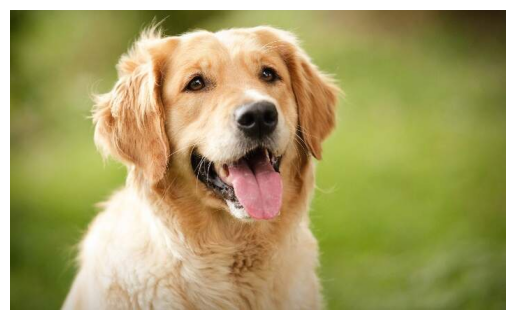

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
from PIL import Image
import numpy as np

# Image URL
img_url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"

# Download image
urllib.request.urlretrieve(img_url, "dog.jpg")

# Read image
img = mpimg.imread("dog.jpg")

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

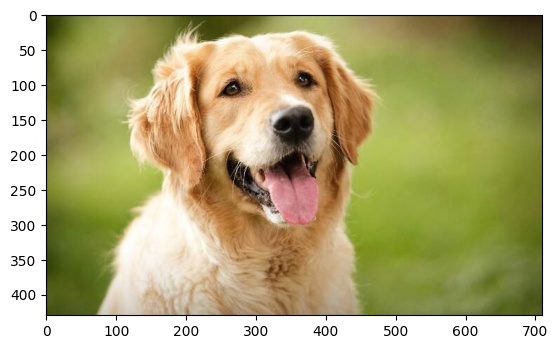

In [8]:
plt.imshow(img)

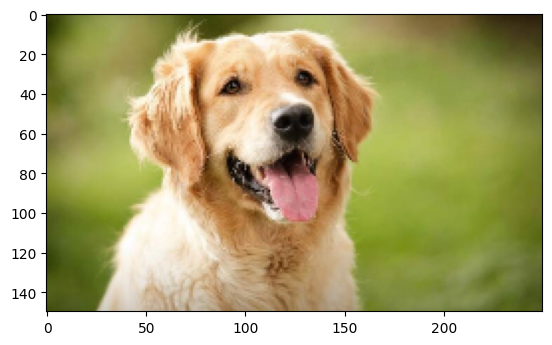

In [12]:
img_rescale = resize (img, (250,150))
plt.imshow(img_rescale)

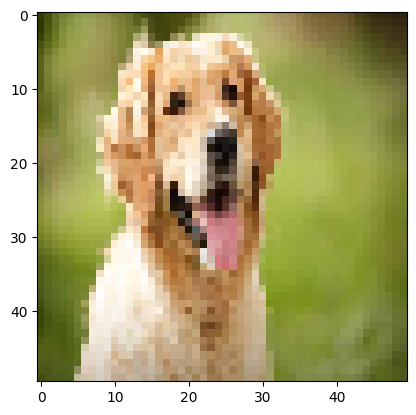

In [13]:
img_rescale = resize (img, (50,50))
plt.imshow(img_rescale)

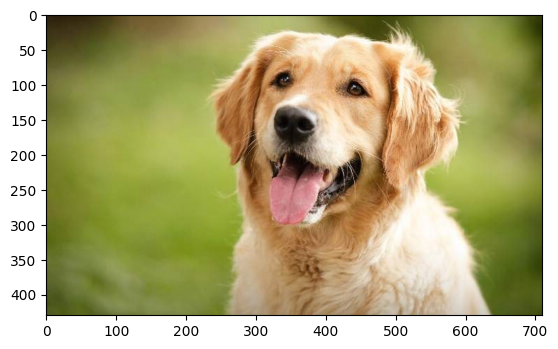

In [14]:
horizontal_flip = np.fliplr(img)
plt.imshow(horizontal_flip)

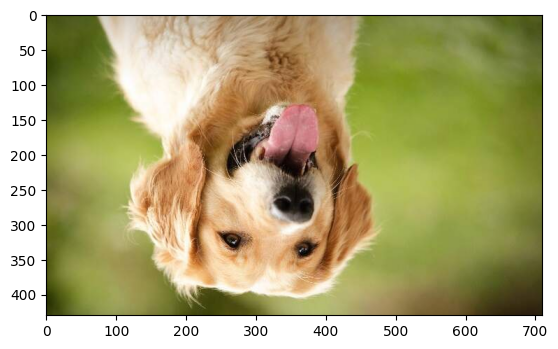

In [15]:
vertical_flip = np.flipud(img)
plt.imshow(vertical_flip)

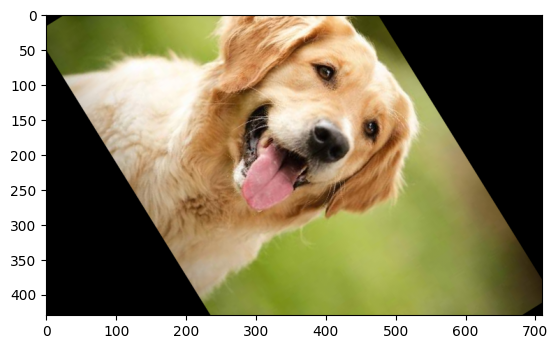

In [18]:
from skimage import transform
trans_img = transform.rotate(img, random.uniform(-80,80))
plt.imshow(trans_img)

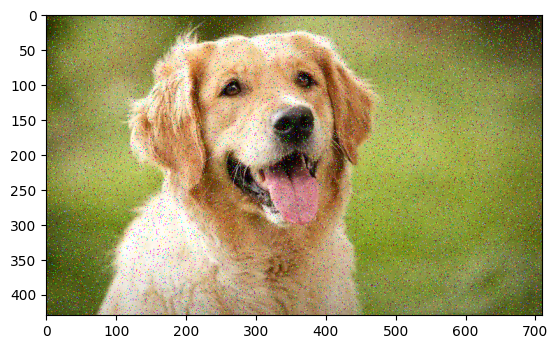

In [20]:
img_noise = random_noise(img, mode='s&p', clip = True)
plt.imshow(img_noise)

Epochs, batch size etc

gradient is - rate of inclination or diclination

desc ent means desending

one epoch is when an entire dataset is passed forward and backward through the neural network only once.

batch size- total number is training examples present in a single batch

batch size n batch num is 2 diff things

iterations- is number of batches needed to complete one epoch.


In [6]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
# Dropout Regularization: To get rid of overfitting problem
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [8]:
num_classes = 10

In [9]:
batch_size = 64
epochs = 24

In [10]:
img_rows, img_cols = 28, 28

In [11]:
# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
x_train.shape

(60000, 28, 28)

In [13]:
x_test.shape

(10000, 28, 28)

In [14]:
len(y_train)

60000

In [15]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [16]:
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

In [17]:
input_shape

(28, 28, 1)

In [18]:
x_train.shape

(60000, 28, 28, 1)

In [19]:
#Type convert and scale the test and training data
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255.
x_test /= 255.
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print(y_train[0:3])

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
[9 0 0]


In [20]:
# convert class vectors to binary class matrices.One-hot encoding
#3 => 0 0 0 1 0 0 0 0 0 0 and 1=> 0100000000
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train[0:2])
# verify one-hot encoding

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [21]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=input_shape
))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(
    32,
    kernel_size=(3, 3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(64, activation='relu'))

# model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(loss=keras.losses.categorical_crossentropy,optimizer = keras.optimizers.Adam(),metrics=['accuracy'])
hist = model.fit(x_train, y_train,
batch_size=batch_size,
epochs=epochs,
verbose=1,
validation_data=(x_test, y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8055 - loss: 0.5397 - val_accuracy: 0.8563 - val_loss: 0.4056
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.8737 - loss: 0.3475 - val_accuracy: 0.8738 - val_loss: 0.3469
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8891 - loss: 0.3014 - val_accuracy: 0.8799 - val_loss: 0.3223
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9021 - loss: 0.2663 - val_accuracy: 0.8885 - val_loss: 0.2987
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9077 - loss: 0.2469 - val_accuracy: 0.9015 - val_loss: 0.2702
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9163 - loss: 0.2264 - val_accuracy: 0.8978 - val_loss: 0.2845
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 74s 42ms/step - accuracy: 0.9244 - loss: 0.2051 - val_accuracy: 0.9076 - val_loss: 0.2593
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.9284 - loss: 0.1911 - 

In [24]:
hist.history

{'accuracy': [0.8054999709129333,
  0.8736666440963745,
  0.889116644859314,
  0.9020833373069763,
  0.9076666831970215,
  0.9163333177566528,
  0.9243500232696533,
  0.9283833503723145,
  0.9334499835968018,
  0.9391166567802429,
  0.9440000057220459,
  0.947866678237915,
  0.9506666660308838,
  0.955216646194458,
  0.9576833248138428,
  0.9613833427429199,
  0.963533341884613,
  0.9661499857902527,
  0.9688166379928589,
  0.9705833196640015,
  0.9729333519935608,
  0.9741166830062866,
  0.9761499762535095,
  0.9782500267028809],
 'loss': [0.5397347807884216,
  0.3475206196308136,
  0.301436185836792,
  0.26628613471984863,
  0.24687927961349487,
  0.22638998925685883,
  0.20513898134231567,
  0.19106759130954742,
  0.17666663229465485,
  0.16263645887374878,
  0.15106238424777985,
  0.1401423066854477,
  0.13034120202064514,
  0.11953424662351608,
  0.11308558285236359,
  0.10235506296157837,
  0.09749794751405716,
  0.08822302520275116,
  0.08242972940206528,
  0.07663022726774216,


Test loss: 0.4334108531475067
Testaccuracy: 0.906000018119812


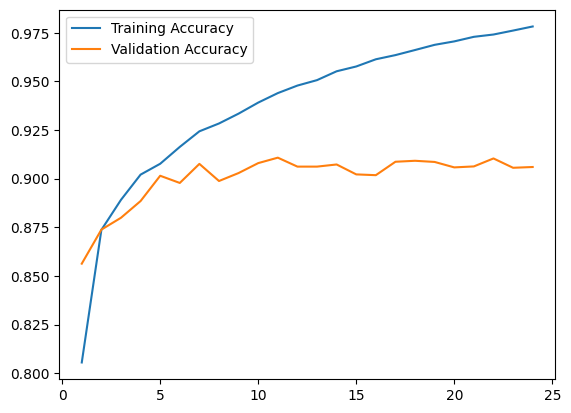

In [23]:
# Evaluate the model with the test data to get the scores on "real" data.
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Testaccuracy:', score[1])
# Plot data to see relationships in training and validation data
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
epoch_list = list(range(1, len(hist.history['accuracy']) + 1)) # values for x axis [1,
plt.plot(epoch_list, hist.history['accuracy'], epoch_list, hist.history['val_accuracy'])
plt.legend(('Training Accuracy', 'Validation Accuracy'))
plt.show()

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)